In [1]:
import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEMENTE_GLOBAL = 42

random.seed(SEMENTE_GLOBAL)
np.random.seed(SEMENTE_GLOBAL)
os.environ['PYTHONHASHSEED'] = str(SEMENTE_GLOBAL)

torch.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed_all(SEMENTE_GLOBAL)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Rodando na: {device}")
print(f"Sementes globais fixadas em {SEMENTE_GLOBAL} para reprodutibilidade.")

Rodando na: cuda
Sementes globais fixadas em 42 para reprodutibilidade.


In [3]:
def extrai_fft_da_imagem(imagem):
    imagem_cinza = imagem.convert("L")

    matriz_cinza = np.array(imagem_cinza, dtype=np.float32) / 255.0

    fft = np.fft.fft2(matriz_cinza)
    fft_centralizada = np.fft.fftshift(fft)

    magnitude = np.log(np.abs(fft_centralizada) + 1e-8)

    minimo = magnitude.min()
    maximo = magnitude.max()

    if maximo - minimo > 1e-8:
        magnitude = (magnitude - minimo) / (maximo - minimo)
    else:
        magnitude = np.zeros_like(magnitude, dtype=np.float32)

    return magnitude

def obtem_normalizacao_imagenet():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

NORMALIZACAO_IMAGENET = obtem_normalizacao_imagenet()

def preparar_entrada_modelo(imagem, magnitude_fft):
    tensor_rgb = NORMALIZACAO_IMAGENET(imagem)

    tensor_fft = torch.tensor(magnitude_fft, dtype=torch.float32).unsqueeze(0)

    entrada = torch.cat([tensor_rgb, tensor_fft], dim=0)

    return entrada

In [4]:
class DatasetComFFT(Dataset):
    def __init__(self, root, tamanho_imagem: int):
        self.dataset = ImageFolder(root)
        self.tamanho_imagem = tamanho_imagem

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        caminho_imagem, rotulo = self.dataset.samples[idx]

        with Image.open(caminho_imagem) as img:
            imagem_rgb = img.convert("RGB")

        imagem_redimensionada = imagem_rgb.resize(
            (self.tamanho_imagem, self.tamanho_imagem),
            Image.Resampling.BILINEAR
        )

        magnitude_fft = extrai_fft_da_imagem(
            imagem=imagem_redimensionada
        )

        entrada = preparar_entrada_modelo(
            imagem=imagem_redimensionada,
            magnitude_fft=magnitude_fft
        )

        return entrada, rotulo

caminho_dataset = "/home/guilhermemathiasreis/Documents/synthetic-face-detection/dataset"
dataset = DatasetComFFT(
    root=caminho_dataset,
    tamanho_imagem= 512
)

print("Classes:", dataset.dataset.classes)
print("Mapeamento label:", dataset.dataset.class_to_idx)

Classes: ['falsas', 'reais']
Mapeamento label: {'falsas': 0, 'reais': 1}


In [5]:
indices = list(range(len(dataset)))
rotulos = [dataset.dataset.samples[i][1] for i in indices]

indices_treino, indices_temp = train_test_split(
    indices,
    test_size=0.4,
    stratify=rotulos,
    random_state=SEMENTE_GLOBAL
)

rotulos_temp = [rotulos[i] for i in indices_temp]

indices_validacao, indices_teste = train_test_split(
    indices_temp,
    test_size=0.5,
    stratify=rotulos_temp,
    random_state=SEMENTE_GLOBAL
)

dataset_treino = torch.utils.data.Subset(dataset, indices_treino)
dataset_validacao = torch.utils.data.Subset(dataset, indices_validacao)
dataset_teste = torch.utils.data.Subset(dataset, indices_teste)

loader_treino = DataLoader(dataset_treino, batch_size=4, shuffle=True)
loader_validacao = DataLoader(dataset_validacao, batch_size=4, shuffle=False)
loader_teste = DataLoader(dataset_teste, batch_size=4, shuffle=False)

In [6]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

camada_conv_original = model.conv1

model.conv1 = nn.Conv2d(
    in_channels=4,
    out_channels=camada_conv_original.out_channels,
    kernel_size=camada_conv_original.kernel_size,
    stride=camada_conv_original.stride,
    padding=camada_conv_original.padding,
    bias=(camada_conv_original.bias is not None)
)

with torch.no_grad():
    model.conv1.weight[:, :3] = camada_conv_original.weight
    model.conv1.weight[:, 3] = camada_conv_original.weight.mean(dim=1)

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
perdas_treino = []
perdas_validacao = []
acuracias_validacao = []

EPOCAS = 10

for epoca in range(EPOCAS):
    print(f"\nÉpoca {epoca + 1}/{EPOCAS}")

    # treino
    model.train()
    perda_treino = 0

    for imagens, rotulos in loader_treino:
        imagens = imagens.to(device)
        rotulos = rotulos.to(device)

        optimizer.zero_grad()

        saidas = model(imagens)

        perda = criterion(saidas, rotulos)

        perda.backward()

        optimizer.step()

        perda_treino += perda.item()

    perda_treino = perda_treino / len(loader_treino)

    # validação
    model.eval()

    perda_validacao = 0
    acertos = 0
    total = 0

    with torch.no_grad():
        for imagens, rotulos in loader_validacao:
            imagens = imagens.to(device)
            rotulos = rotulos.to(device)

            saidas = model(imagens)

            perda = criterion(saidas, rotulos)

            perda_validacao += perda.item()

            _, previstos = torch.max(saidas, 1)

            total += rotulos.size(0)
            acertos += (previstos == rotulos).sum().item()

    perda_validacao = perda_validacao / len(loader_validacao)
    acuracia_validacao = 100 * acertos / total

    perdas_treino.append(perda_treino)
    perdas_validacao.append(perda_validacao)
    acuracias_validacao.append(acuracia_validacao)

    print(f"Loss Treino   : {perda_treino:.4f}")
    print(f"Loss Validação: {perda_validacao:.4f}")
    print(f"Acurácia Val  : {acuracia_validacao:.2f}%")


Época 1/10
Loss Treino   : 0.2447
Loss Validação: 0.0684
Acurácia Val  : 97.85%

Época 2/10
Loss Treino   : 0.0948
Loss Validação: 0.0259
Acurácia Val  : 99.50%

Época 3/10
Loss Treino   : 0.0574
Loss Validação: 0.0399
Acurácia Val  : 98.55%

Época 4/10
Loss Treino   : 0.0421
Loss Validação: 0.0316
Acurácia Val  : 98.90%

Época 5/10
Loss Treino   : 0.0352
Loss Validação: 0.0371
Acurácia Val  : 98.80%

Época 6/10
Loss Treino   : 0.0259
Loss Validação: 0.3610
Acurácia Val  : 96.15%

Época 7/10
Loss Treino   : 0.0231
Loss Validação: 0.0974
Acurácia Val  : 97.80%

Época 8/10
Loss Treino   : 0.0218
Loss Validação: 0.0712
Acurácia Val  : 98.05%

Época 9/10
Loss Treino   : 0.0278
Loss Validação: 0.0702
Acurácia Val  : 97.85%

Época 10/10
Loss Treino   : 0.0122
Loss Validação: 0.0774
Acurácia Val  : 97.90%


              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1000
           1       0.99      0.97      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



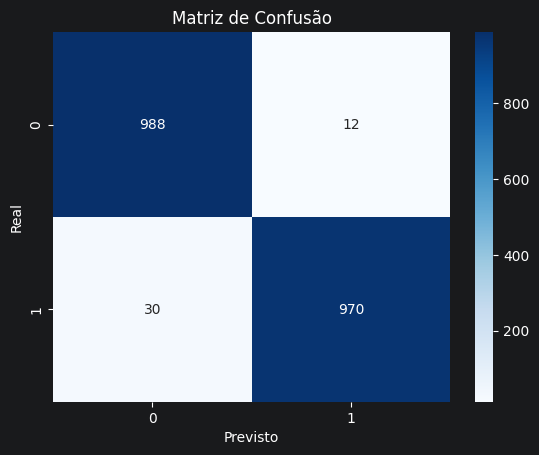

In [9]:
rotulos_reais = []
rotulos_previstos = []

model.eval()

with torch.no_grad():
    for imagens, rotulos in loader_teste:
        imagens = imagens.to(device)
        saidas = model(imagens)
        _, previstos = torch.max(saidas, 1)
        rotulos_reais.extend(rotulos.tolist())
        rotulos_previstos.extend(previstos.cpu().tolist())

print(classification_report(rotulos_reais, rotulos_previstos))

matriz_confusao = confusion_matrix(rotulos_reais, rotulos_previstos)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [10]:
PASTA_MODELOS = "../models"

os.makedirs(PASTA_MODELOS, exist_ok=True)

torch.save(model.state_dict(),f"{PASTA_MODELOS}/train_rgb_fft_512.pth")

print("modelo salvo em /models")

modelo salvo em /models
